# Notebook 3: Building up to quantum cellular automata - Semiclassical cellular automata

Roadplan:
- Building up Markov transition matrices
- Change dynamics function so that it uses a probabilistic approach for the cells given or the entire lattice.
- Look at other function to change
- Plot some classical vs semiclassical
- Extending markov chains to semiclassical automata

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import random
import itertools

In [39]:
# From Notebook 1

from Functions_for_Notebook_1 import make_rule, make_rule_zero_condition, make_rule_symmetry #For making the rules

from Functions_for_Notebook_1 import dynamics, dynamics_reflection, dynamics_periodic #For the dynamics

from Functions_for_Notebook_1 import plot_grid #For the plotting

from Functions_for_Notebook_1 import complement_rule

In [40]:
# From Notebook 2
from Functions_for_Notebook_2 import plot_grid_multiple, plot_multiple_cells, dynamics_initialandfinal #To grid multiple systems

from Functions_for_Notebook_2 import is_rule

from Functions_for_Notebook_2 import is_reversible, gardens_of_eden

## 1. Building up Markov Transition Matrices
https://www.youtube.com/watch?v=Hmzfv9dqw94

https://www.youtube.com/watch?v=i3AkTO9HLXo&list=PLM8wYQRetTxBkdvBtz-gw8b9lcVkdXQKV

General markov chains have the characteristic that the future state only depends on the current state and the probabilities of all posssible subsequent states add up to one (just like elementary CA).

Therefore, a transition matrix can be computed for the evolution of CA system, dependent on the rule and lattice length.

The end goal is to have two functions that print out a vector representation of the initial state and a function that prints out the transition matric for that evolution.

In [41]:
def vectorized_ic(L, initial_conditions):
    import itertools
    
    # build the lattice row — length L
    row = np.zeros(L, dtype=int)
    row[initial_conditions] = 1       
    
    # find which index in all_states this corresponds to
    all_states = list(itertools.product([0, 1], repeat=L))
    index      = all_states.index(tuple(row))  
    
    # return a vector of length 2^L with a 1 at that index
    v = np.zeros(2**L, dtype=int)
    v[index] = 1
    return v

print(vectorized_ic(10, [1,3,5]))

print(vectorized_ic(2, [1]))

[0 0 0 ... 0 0 0]
[0 1 0 0]


This vectorized_is function takes the state defined by L and the initial conditions and returns a probability vector where all components are 0 except for the i'th component, which is one, where i is the component at the position that that same position later occupies in the transition matrix.

The next_state function is just for convenience:

In [42]:
def next_state(state, rule_number, L): #This code comes up in several functions so it is better to automate it
    rule   = make_rule(rule_number)
    result = []
    for i in range(L):
        left   = str(int(state[i - 1])) if i > 0 else '0'      
        center = str(int(state[i]))
        right  = str(int(state[i + 1])) if i < L - 1 else '0'    
        neighbourhood = left + center + right
        result.append(rule[neighbourhood])
    return tuple(result)

print(next_state([1,0,1,0], 255, 4))
print("")
print(next_state([1,0,1,0], 0, 4))
print("")
print(next_state([1,0,1,1], 90, 4))
print(next_state([1,1,1,0], 90, 4))
print(next_state([0,1,1,1], 90, 4))

(1, 1, 1, 1)

(0, 0, 0, 0)

(0, 0, 1, 1)
(1, 0, 1, 1)
(1, 1, 0, 1)


The logic behind the Markov chain will be that the i and j will be the input and output possible lattices, so it will be a permutation of the lattice length, meaning the markov chain for larger lattices will not be an efficient approach:

In [43]:
def markov_matrix_mapping(rule_number: int, L: int):
    import itertools

    all_states   = list(itertools.product([0, 1], repeat=L))
    n            = len(all_states)
    state_labels = [''.join(str(b) for b in s) for s in all_states]

    M = markov_matrix(rule_number, L)  # reuse the correct matrix

    print(f"\nTransition matrix — Rule {rule_number}, L={L}")
    print(f"Row = next state   Col = current state\n")
    print("        " + "  ".join(state_labels))
    print("       " + "---" * n)

    for i, state in enumerate(all_states):          # i = row = next state
        label = state_labels[i]
        row   = "  ".join(str(M[i][j]) for j in range(n))   # j = col = current state
        print(f"{label}  |  {row}")



def markov_matrix(rule_number: int, L: int):
    import itertools

    rule = make_rule(rule_number)
    all_states = list(itertools.product([0, 1], repeat=L))
    n  = len(all_states)

    M = np.zeros((n, n), dtype=int)

    state_labels = [''.join(str(b) for b in s) for s in all_states]

    for j, state in enumerate(all_states):
        nxt = next_state(state, rule_number, L)   
        i   = all_states.index(nxt)
        M[i][j] = 1
        label = ''.join(str(b) for b in state)
        row  = "  ".join(str(M[k][j]) for k in range(n))

    return M

print(markov_matrix_mapping(0, 2 ))

print(markov_matrix_mapping(255, 2 ))

print(markov_matrix_mapping(127, 2 ))

print(markov_matrix(0, 2 ))

print(markov_matrix(255, 2 ))

print(markov_matrix(23, 2 ))


Transition matrix — Rule 0, L=2
Row = next state   Col = current state

        00  01  10  11
       ------------
00  |  1  1  1  1
01  |  0  0  0  0
10  |  0  0  0  0
11  |  0  0  0  0
None

Transition matrix — Rule 255, L=2
Row = next state   Col = current state

        00  01  10  11
       ------------
00  |  0  0  0  0
01  |  0  0  0  0
10  |  0  0  0  0
11  |  1  1  1  1
None

Transition matrix — Rule 127, L=2
Row = next state   Col = current state

        00  01  10  11
       ------------
00  |  0  0  0  0
01  |  0  0  0  0
10  |  0  0  0  0
11  |  1  1  1  1
None
[[1 1 1 1]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [1 1 1 1]]
[[0 0 0 1]
 [0 0 0 0]
 [0 0 0 0]
 [1 1 1 0]]


In [44]:
result = markov_matrix(3, 3) @ vectorized_ic(3, [1,2])

result 

array([0, 0, 0, 0, 1, 0, 0, 0])

### Developing a dynamics function that uses matrices
We'll take the inputs of this function the same as of the other dynamics function:

In [45]:
def dynamics_matrix(rule_number, L, initial_conditions, timesteps):

    def decode_state(index, L):
        """Inverse of vectorized_ic's binary indexing convention."""
        return np.array([(index >> (L - 1 - i)) & 1 for i in range(L)], dtype=int)

    M = markov_matrix(rule_number, L)
    vector = vectorized_ic(L, initial_conditions)

    rows = [decode_state(np.argmax(vector), L)]   # t=0
    for _ in range(timesteps):
        vector = M @ vector
        rows.append(decode_state(np.argmax(vector), L))

    grid = np.array(rows[::-1])   # earliest at bottom, matching dynamics()
    return grid


print(dynamics_matrix(90,4,[1, 2], 9))
    

[[0 1 1 0]
 [1 0 0 1]
 [1 1 1 1]
 [0 1 1 0]
 [1 0 0 1]
 [1 1 1 1]
 [0 1 1 0]
 [1 0 0 1]
 [1 1 1 1]
 [0 1 1 0]]


### Proving the function works:
To prove the Markov chain approach works, we build up two functions that perform the same, obtaining the state of a system at a certain timestep.

First version of the function does that through the dynamics function:

In [46]:
system = dynamics(99, 10, [1,4,7], 10)

In [47]:
def state_timestep_1(system, timestep):
    return system[-(timestep + 1)]

print(state_timestep_1(system, 3))

print(state_timestep_1(system, 0))

[1 1 0 0 1 0 0 1 0 0]
[0 1 0 0 1 0 0 1 0 0]


The second version computes the timestep as a matrix multiplication:

In [48]:
rule = 3
ic = [1,2]
system = dynamics(rule, 3, ic, 10)

def state_timestep_2(rule, system, ic, timestep):
    L = len(system[-1])
    v = vectorized_ic(L, ic)
    M =  markov_matrix(rule, L)

    for _ in range(timestep):
        v = M @ v

    #Convert the probability vector back into the cell values
    all_states = list(itertools.product([0, 1], repeat=L))
    index      = np.argmax(v) 
    return np.array(all_states[index])

print(state_timestep_2(rule, system, ic, 3))

print(state_timestep_2(rule, system,ic, 0))

[1 1 0]
[0 1 1]


Now we verify that this matches for different systems:

In [49]:
ic =[5,7]
timestep = 10
L = 10
rule = 90

system_1 = dynamics(rule, 10, ic, timestep)
system_2 = dynamics(rule, 10, ic, timestep)
system_3 = dynamics(rule, 10, ic, timestep)
system_4 = dynamics(rule, 10, ic, timestep)
system_5 = dynamics(rule, 10, ic, timestep)

lst = [system_1, system_2, system_3, system_4, system_5]


all_match = True  


for system in lst:
    for t in range(10):
        s1 = state_timestep_1(system, timestep)
        s2 = state_timestep_2(rule, system, ic, timestep)
        if not np.allclose(s1, s2):
            all_match = False
            break      
    if not all_match:
        break      

print(all_match)
        

   

True


We'll stick to the first approach because it requires less inputs and works for longer lattices:

In [50]:
def state_timestep(system, timestep):
    return system[:timestep]

### Let us determine if the two dynamics functions match:

In [51]:
print(np.allclose(dynamics_matrix(3,4,[1,2], 9), dynamics(3,4,[1,2], 9) ))

print(np.allclose(dynamics_matrix(90,8,[1,2], 90), dynamics(90,8,[1,2], 90) ))

True
True


It works.

## 2. Study of Markov Transition Matrices for These Systems
Here we study the properties of the single-step transition matrix `M` — the matrix that maps
a probability vector for the state at time `t` to the state at time `t+1` — as opposed to the
full multi-timestep evolution studied via `dynamics()`.

### 2.1) Structure of a single transition step
Since the CA rule is deterministic, every state maps to exactly one next state, so every
*column* of `M` sums to exactly 1. Rows, however, can sum to more than 1 (many states
collapsing onto the same next state) or to 0 (states nothing maps to). We verify this
numerically below.

### 2.2) Reversibility and Gardens of Eden, in matrix language
A rule is reversible iff `M` is a permutation matrix (equivalently, `det(M) ≠ 0`). Garden-of-Eden
states — states with no predecessor — correspond exactly to the all-zero rows of `M`. We connect
this back to `is_reversible` and `gardens_of_eden` from Notebook 2.

### 2.3) Fixed points and short cycles
`M[i][i] = 1` identifies a fixed state under one application of the rule. More generally, a 1
reappearing at the starting index in `M^k` identifies a cycle of length `k`.

### 2.4) Scaling of the state space
The matrix has shape `2^L × 2^L`, so this approach is only tractable for small `L`. A short
table/plot of `L` vs. matrix size makes this concrete and motivates why later sections keep `L`
small.

### 2.5) Visualizing `M` across rule classes
A heatmap of `M` for a few rules spanning different Wolfram classes (e.g. 90, 110, 30) to see
qualitative structural differences before any eigenvalue analysis.

### 2.6) Rank and reachable states
`np.linalg.matrix_rank(M)` (or the number of distinct reachable next-states) gives a cheap
first measure of how compressive a rule is, previewing both reversibility and later
effective-complexity work.

## 3. Adjusting previous functions to account for a probabilistic approach
### 3.1) Dynamics function

First, we define a function for probablistic approaches and see if it can be tirned into a generalization of the previous dynamics function.

Firstly, define a new function that for the initial conditions has an associated list with the probability that it is one, then add an option such that if only one value is put in for the probabilities, then that probability applied for all initial conditions. We can also define it such that if no probabilities are specified, the function reverts back to its classical version. 

In [52]:
def probabilistic_dynamics(rule_number, L, initial_conditions, probability_list, timesteps):
    if not (0 <= rule_number <= 255):
        raise ValueError("Rule number not appropriate")
    
    if probability_list is None:
        return dynamics(rule_number, L, initial_conditions, timesteps)
    
    elif isinstance(probability_list, float):
        new_list = []
        for i in range(len(initial_conditions)):
            new_list.append(probability_list)
        probability_list = new_list

    elif len(initial_conditions) != len(probability_list):
        raise ValueError("Each initial condition must have an associated probability")

    rule_bin = format(rule_number, '08b')
    neighbourhoods = [format(i, '03b') for i in range(7, -1, -1)]
    rule = {n: int(b) for n, b in zip(neighbourhoods, rule_bin)} #Previous function for the rule

    # Set up initial row
    row = np.zeros(L, dtype=int)

    for i, probability in zip(initial_conditions, probability_list):
        row[i] = 1 if random.random() < probability else 0
    rows = [row.copy()] #So we take an independent "snapshot"


    # Evolve through timesteps
    for i in range(timesteps):
        new_row = np.zeros(L, dtype=int)
        for j in range(L):
            left   = str(int(rows[-1][j - 1])) if j > 0 else '0'       # zero boundary
            centre = str(int(rows[-1][j]))
            right  = str(int(rows[-1][j + 1])) if j < L - 1 else '0'   # zero boundary
            neighbourhood = left + centre + right
            new_row[j] = rule[neighbourhood]
        rows.append(new_row)

    grid = np.vstack(rows[::-1])
    return grid

print(probabilistic_dynamics(3, 9, [], None , 9))
print(probabilistic_dynamics(3, 9, [1,2,3], [0.3,0.6,0.7] , 9))

[[1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0]]
[[1 1 1 1 1 1 1 0 0]
 [0 0 0 0 0 0 0 1 0]
 [1 1 1 1 1 1 0 0 1]
 [0 0 0 0 0 0 1 0 0]
 [1 1 1 1 1 0 0 1 1]
 [0 0 0 0 0 1 0 0 0]
 [1 1 1 1 0 0 1 1 1]
 [0 0 0 0 1 0 0 0 0]
 [1 1 1 0 0 1 1 1 1]
 [0 0 0 1 0 0 0 0 0]]


To prove it works, we can prove it in different steps: 

1. The semiclassical arrays for the case where the probability is zero must match the classical dynamics that don't include the value for which the probabolity is zero as an initial starting point in the first place.

In [53]:
np.allclose(probabilistic_dynamics(23, 10, [1,2,3, 4], [1,1,1, 0], 10), dynamics(23, 10, [1,2,3], 10))

np.allclose(probabilistic_dynamics(23, 1000, [1,20,33, 4], [1,1,1, 0], 1000), dynamics(23, 1000, [1,20,33], 1000))



True

2. The absolute same function can give different results and will most likely for a large number of initial conditions

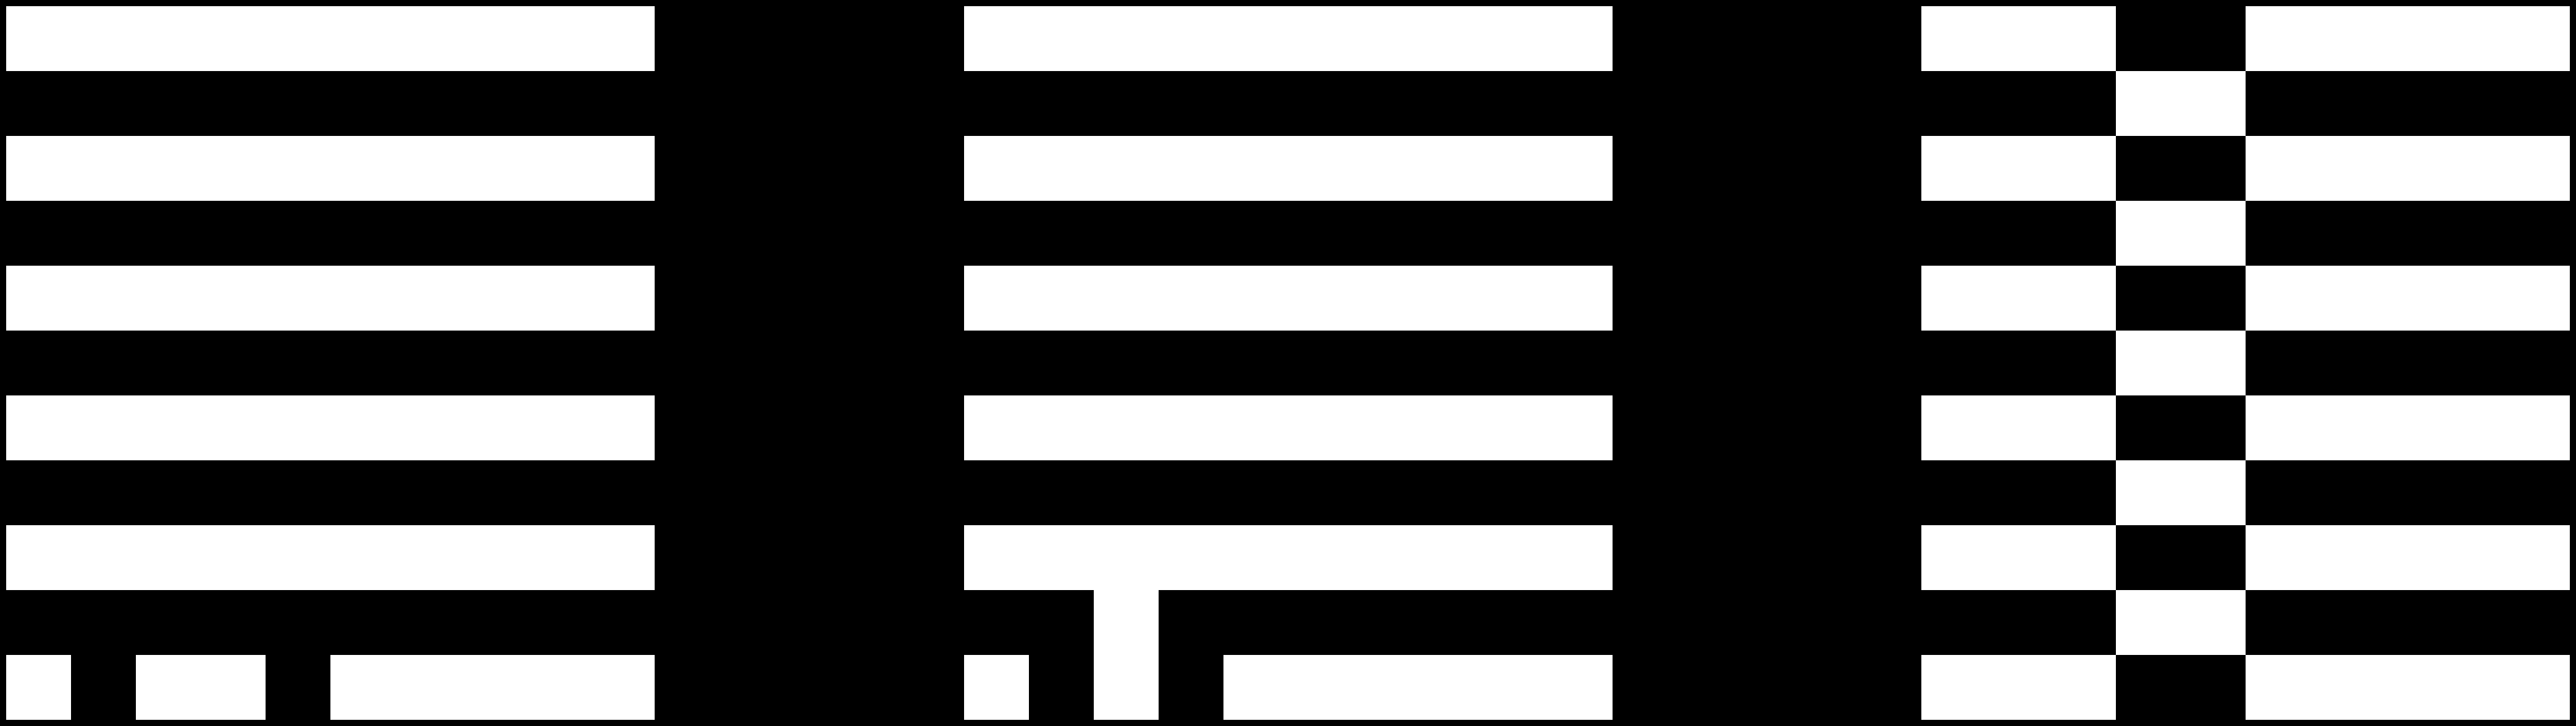

In [54]:
plot_grid_multiple([probabilistic_dynamics(23, 10, [1,2,3,4], [0.5,0.5,0.5,0.5], 10), probabilistic_dynamics(23, 10, [1,2,3,4], [0.5,0.5,0.5,0.5], 10), probabilistic_dynamics(23, 10, [1,2,3,4], [0.5,0.5,0.5,0.5], 10)], cols=3)

### 3.2) Other functions


Other functions that can / must be adjusted to account for semiprobabilistic conditions are the following:
- Dynamics functions for the different boundary conditions
- The markov chains

The markov chains will be dealt with in a different section:

In [55]:
def probabilistic_dynamics_periodic(rule_number, L, initial_conditions, probability_list, timesteps):
    if not (0 <= rule_number <= 255):
        raise ValueError("Rule number not appropriate")
    
    if probability_list is None:
        return dynamics_periodic(rule_number, L, initial_conditions, timesteps)
    
    elif isinstance(probability_list, float):
        new_list = []
        for i in range(len(initial_conditions)):
            new_list.append(probability_list)
        probability_list = new_list

    elif len(initial_conditions) != len(probability_list):
        raise ValueError("Each initial condition must have an associated probability")

    rule_bin = format(rule_number, '08b')
    neighbourhoods = [format(i, '03b') for i in range(7, -1, -1)]
    rule = {n: int(b) for n, b in zip(neighbourhoods, rule_bin)} #Previous function for the rule

    # Set up initial row
    row = np.zeros(L, dtype=int)

    for i, probability in zip(initial_conditions, probability_list):
        row[i] = 1 if random.random() < probability else 0
    rows = [row.copy()] #So we take an independent "snapshot"


    # Evolve through timesteps
    for i in range(timesteps):
        new_row = np.zeros(L, dtype=int)
        for j in range(L):
            left   = str(int(rows[-1][(j - 1) % L]))  # periodic boundary
            centre = str(int(rows[-1][j]))
            right  = str(int(rows[-1][(j + 1) % L]))   
            neighbourhood = left + centre + right
            new_row[j] = rule[neighbourhood]
        rows.append(new_row)

    grid = np.vstack(rows[::-1])
    return grid

In [56]:
def probabilistic_dynamics_reflection(rule_number, L, initial_conditions, probability_list, timesteps):
    if not (0 <= rule_number <= 255):
        raise ValueError("Rule number not appropriate")
    
    if probability_list is None:
        return dynamics_reflection(rule_number, L, initial_conditions, timesteps)
    
    elif isinstance(probability_list, float):
        new_list = []
        for i in range(len(initial_conditions)):
            new_list.append(probability_list)
        probability_list = new_list

    elif len(initial_conditions) != len(probability_list):
        raise ValueError("Each initial condition must have an associated probability")

    rule_bin = format(rule_number, '08b')
    neighbourhoods = [format(i, '03b') for i in range(7, -1, -1)]
    rule = {n: int(b) for n, b in zip(neighbourhoods, rule_bin)} #Previous function for the rule

    # Set up initial row
    row = np.zeros(L, dtype=int)

    for i, probability in zip(initial_conditions, probability_list):
        row[i] = 1 if random.random() < probability else 0
    rows = [row.copy()] #So we take an independent "snapshot"


    # Evolve through timesteps
    for i in range(timesteps):
        new_row = np.zeros(L, dtype=int)
        for j in range(L):
            left   = str(int(rows[-1][j + 1])) if j == 0 else str(int(rows[-1][j - 1]))  #mirror reflection
            centre = str(int(rows[-1][j]))
            right  = str(int(rows[-1][j - 1])) if j == L - 1 else str(int(rows[-1][j + 1]))
            neighbourhood = left + centre + right
            new_row[j] = rule[neighbourhood]
        rows.append(new_row)

    grid = np.vstack(rows[::-1])
    return grid

In [57]:
def probabilistic_dynamics_initialandfinal(rule_number, L, initial_conditions, probability_list, timesteps):
    if not (0 <= rule_number <= 255):
        raise ValueError("Rule number not appropriate")
    
    if probability_list is None:
        return probabilistic_dynamics_initialandfinal(rule_number, L, initial_conditions, timesteps)
    
    elif isinstance(probability_list, float):
        new_list = []
        for i in range(len(initial_conditions)):
            new_list.append(probability_list)
        probability_list = new_list

    elif len(initial_conditions) != len(probability_list):
        raise ValueError("Each initial condition must have an associated probability")

    rule_bin = format(rule_number, '08b')
    neighbourhoods = [format(i, '03b') for i in range(7, -1, -1)]
    rule = {n: int(b) for n, b in zip(neighbourhoods, rule_bin)} #Previous function for the rule

    # Set up initial row
    row = np.zeros(L, dtype=int)

    for i, probability in zip(initial_conditions, probability_list):
        row[i] = 1 if random.random() < probability else 0
    rows = [row.copy()] #So we take an independent "snapshot"


    # Evolve through timesteps
    for i in range(timesteps):
        new_row = np.zeros(L, dtype=int)
        for j in range(L):
            left   = str(int(rows[-1][j - 1])) if j > 0 else '0'       # zero boundary
            centre = str(int(rows[-1][j]))
            right  = str(int(rows[-1][j + 1])) if j < L - 1 else '0'   # zero boundary
            neighbourhood = left + centre + right
            new_row[j] = rule[neighbourhood]
        rows.append(new_row)

    grid = np.vstack(rows[::-1])
    return rows[0], "->", rows[-1]

## 4. Plotting rules against their semiclassical counterparts
Comparing the evolution of semiclassical systems to their purely classical counterparts.

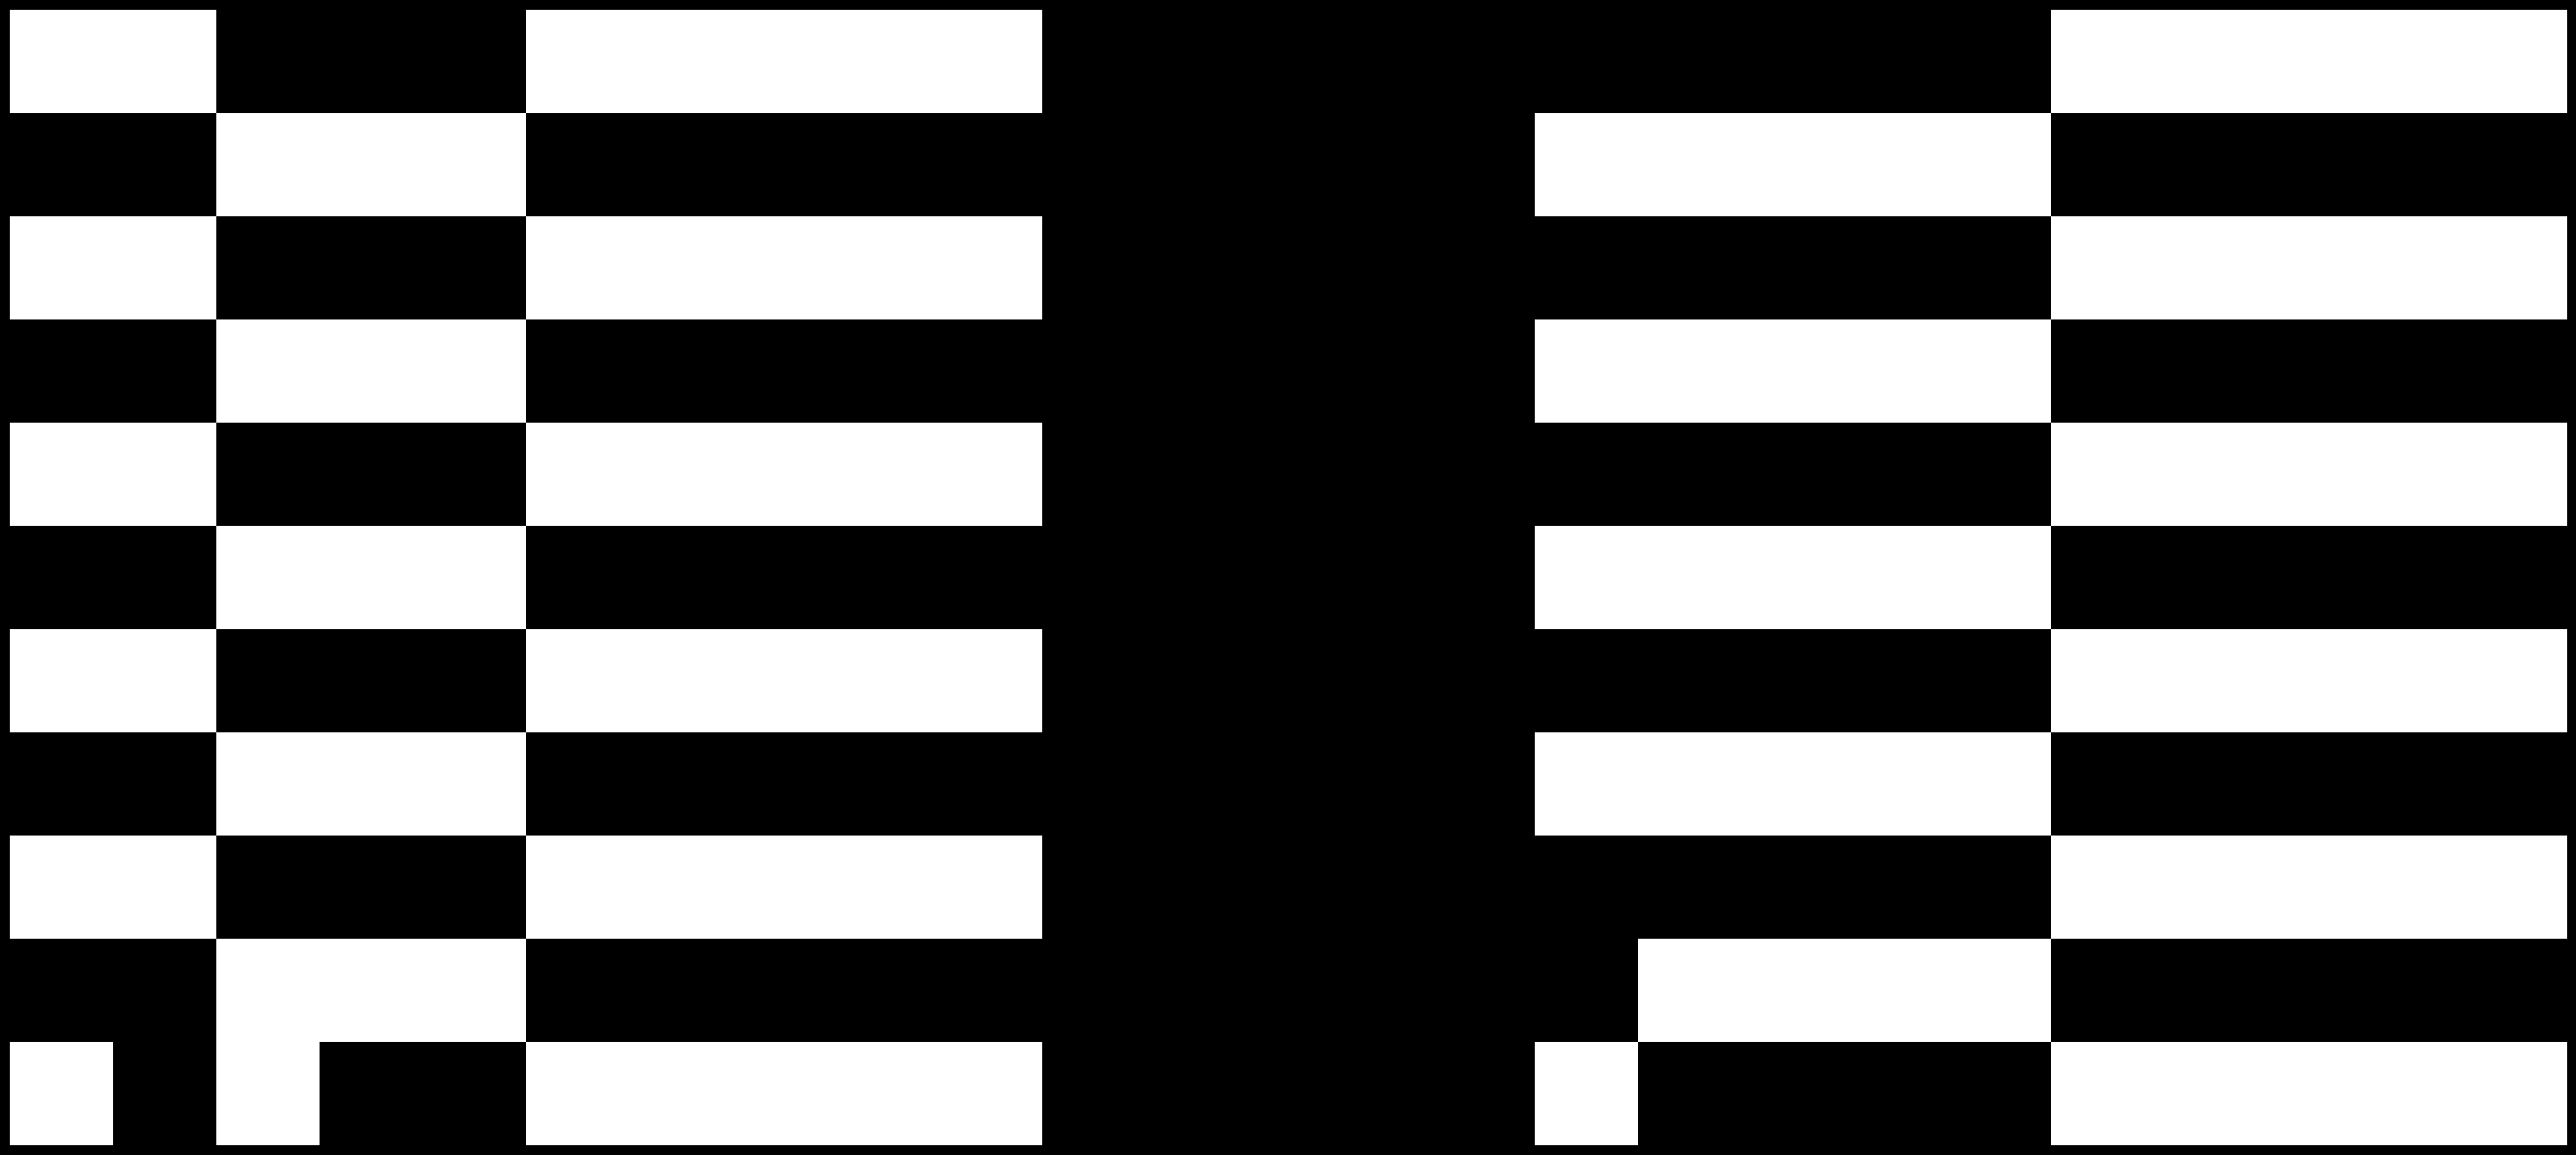

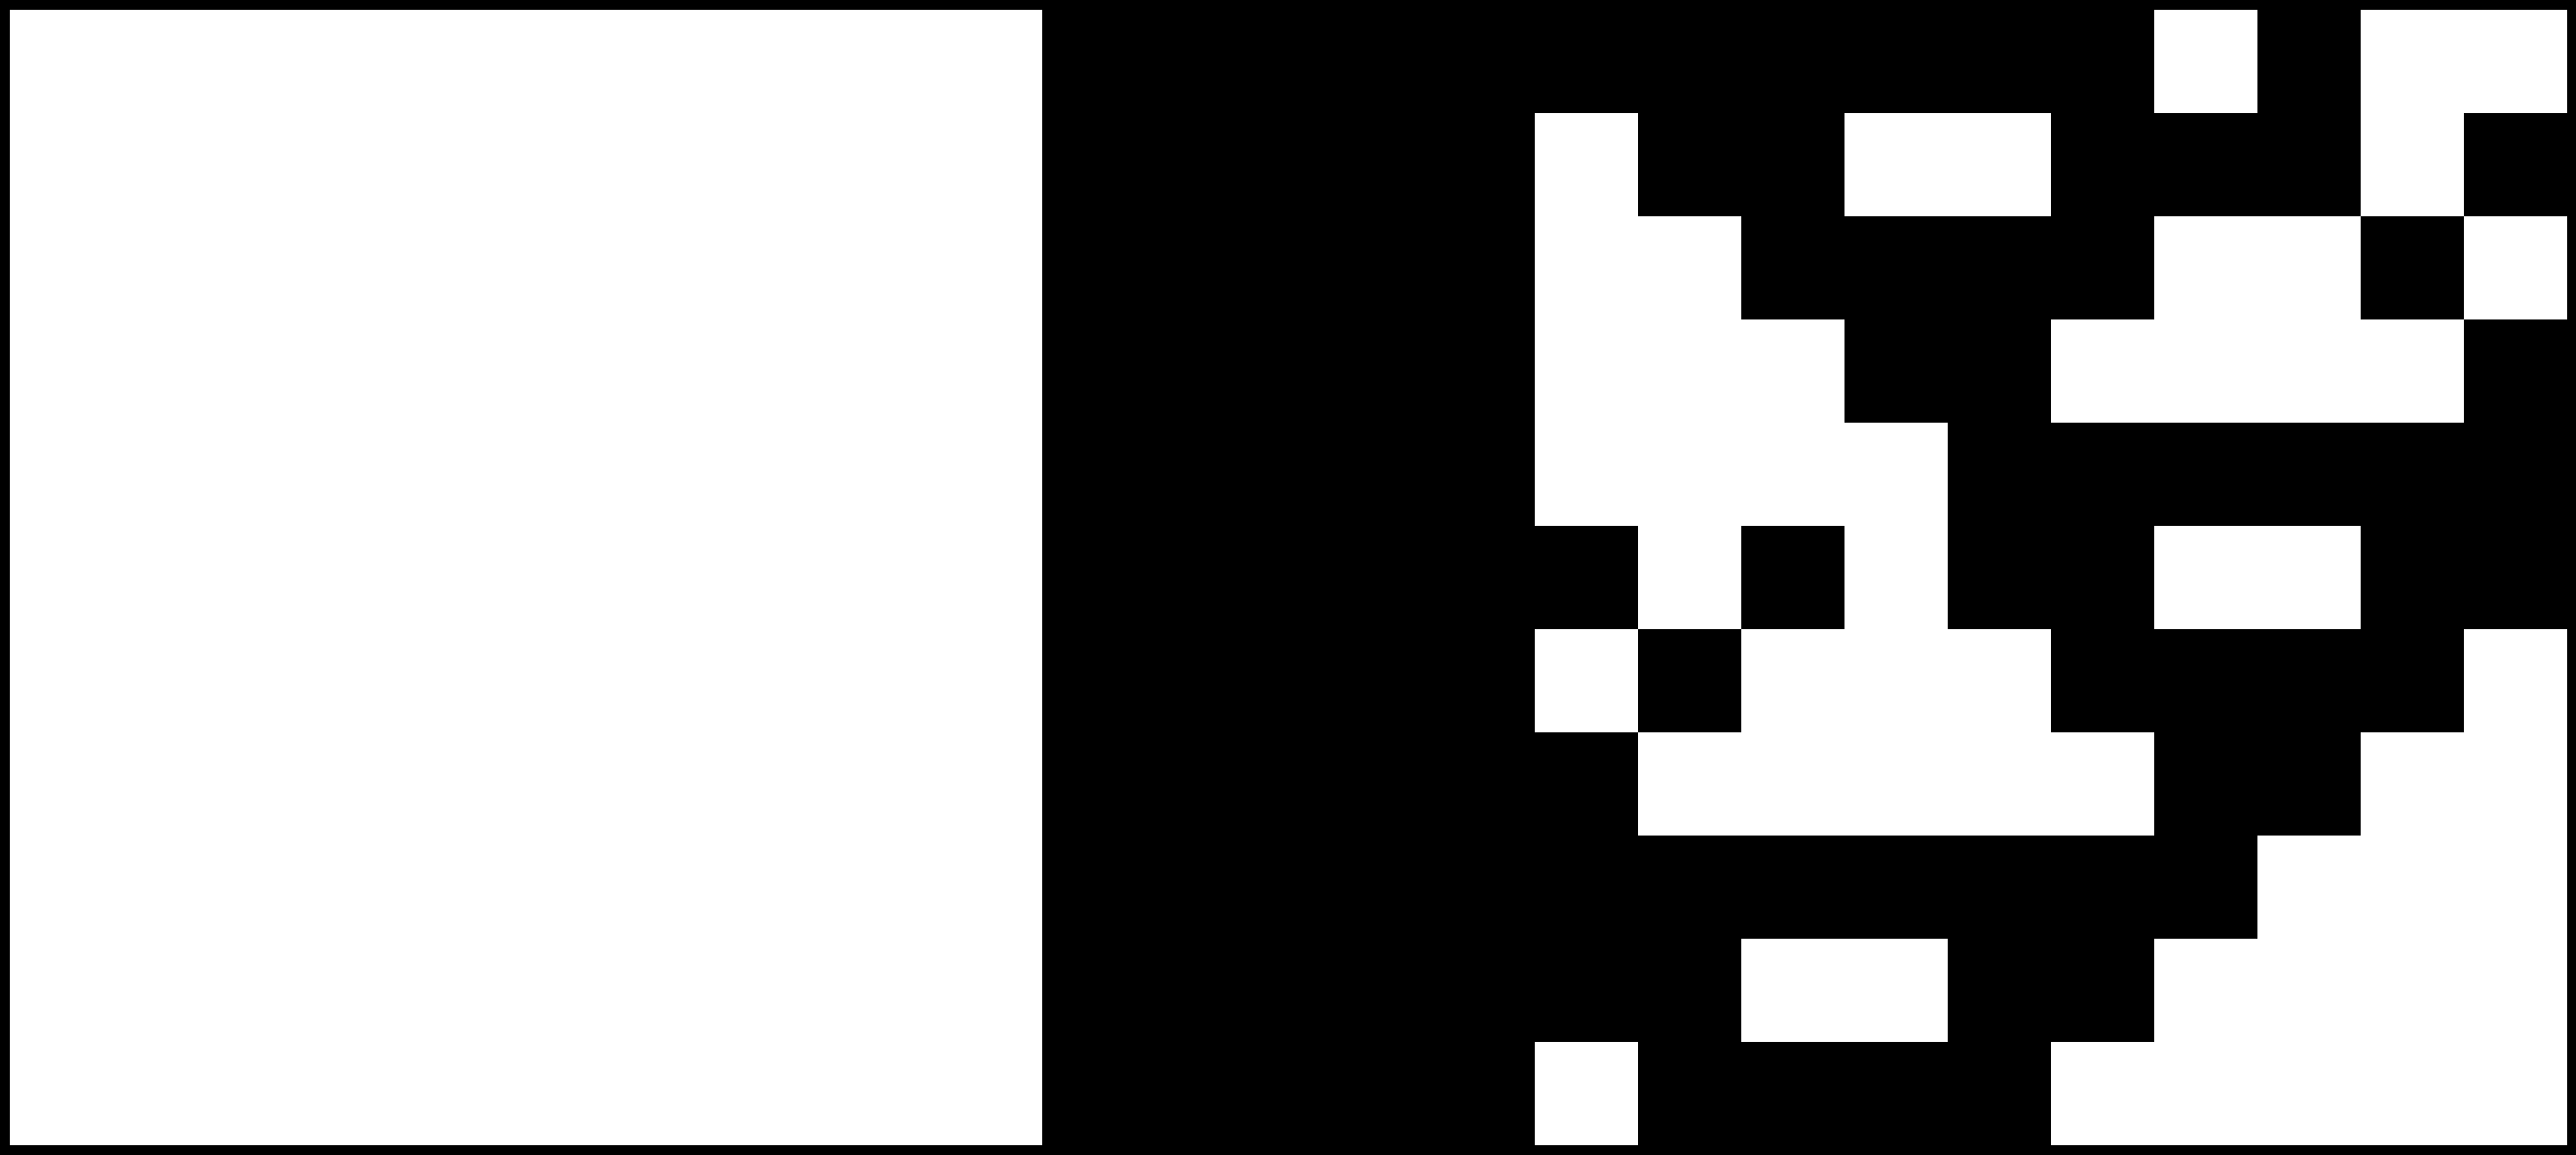

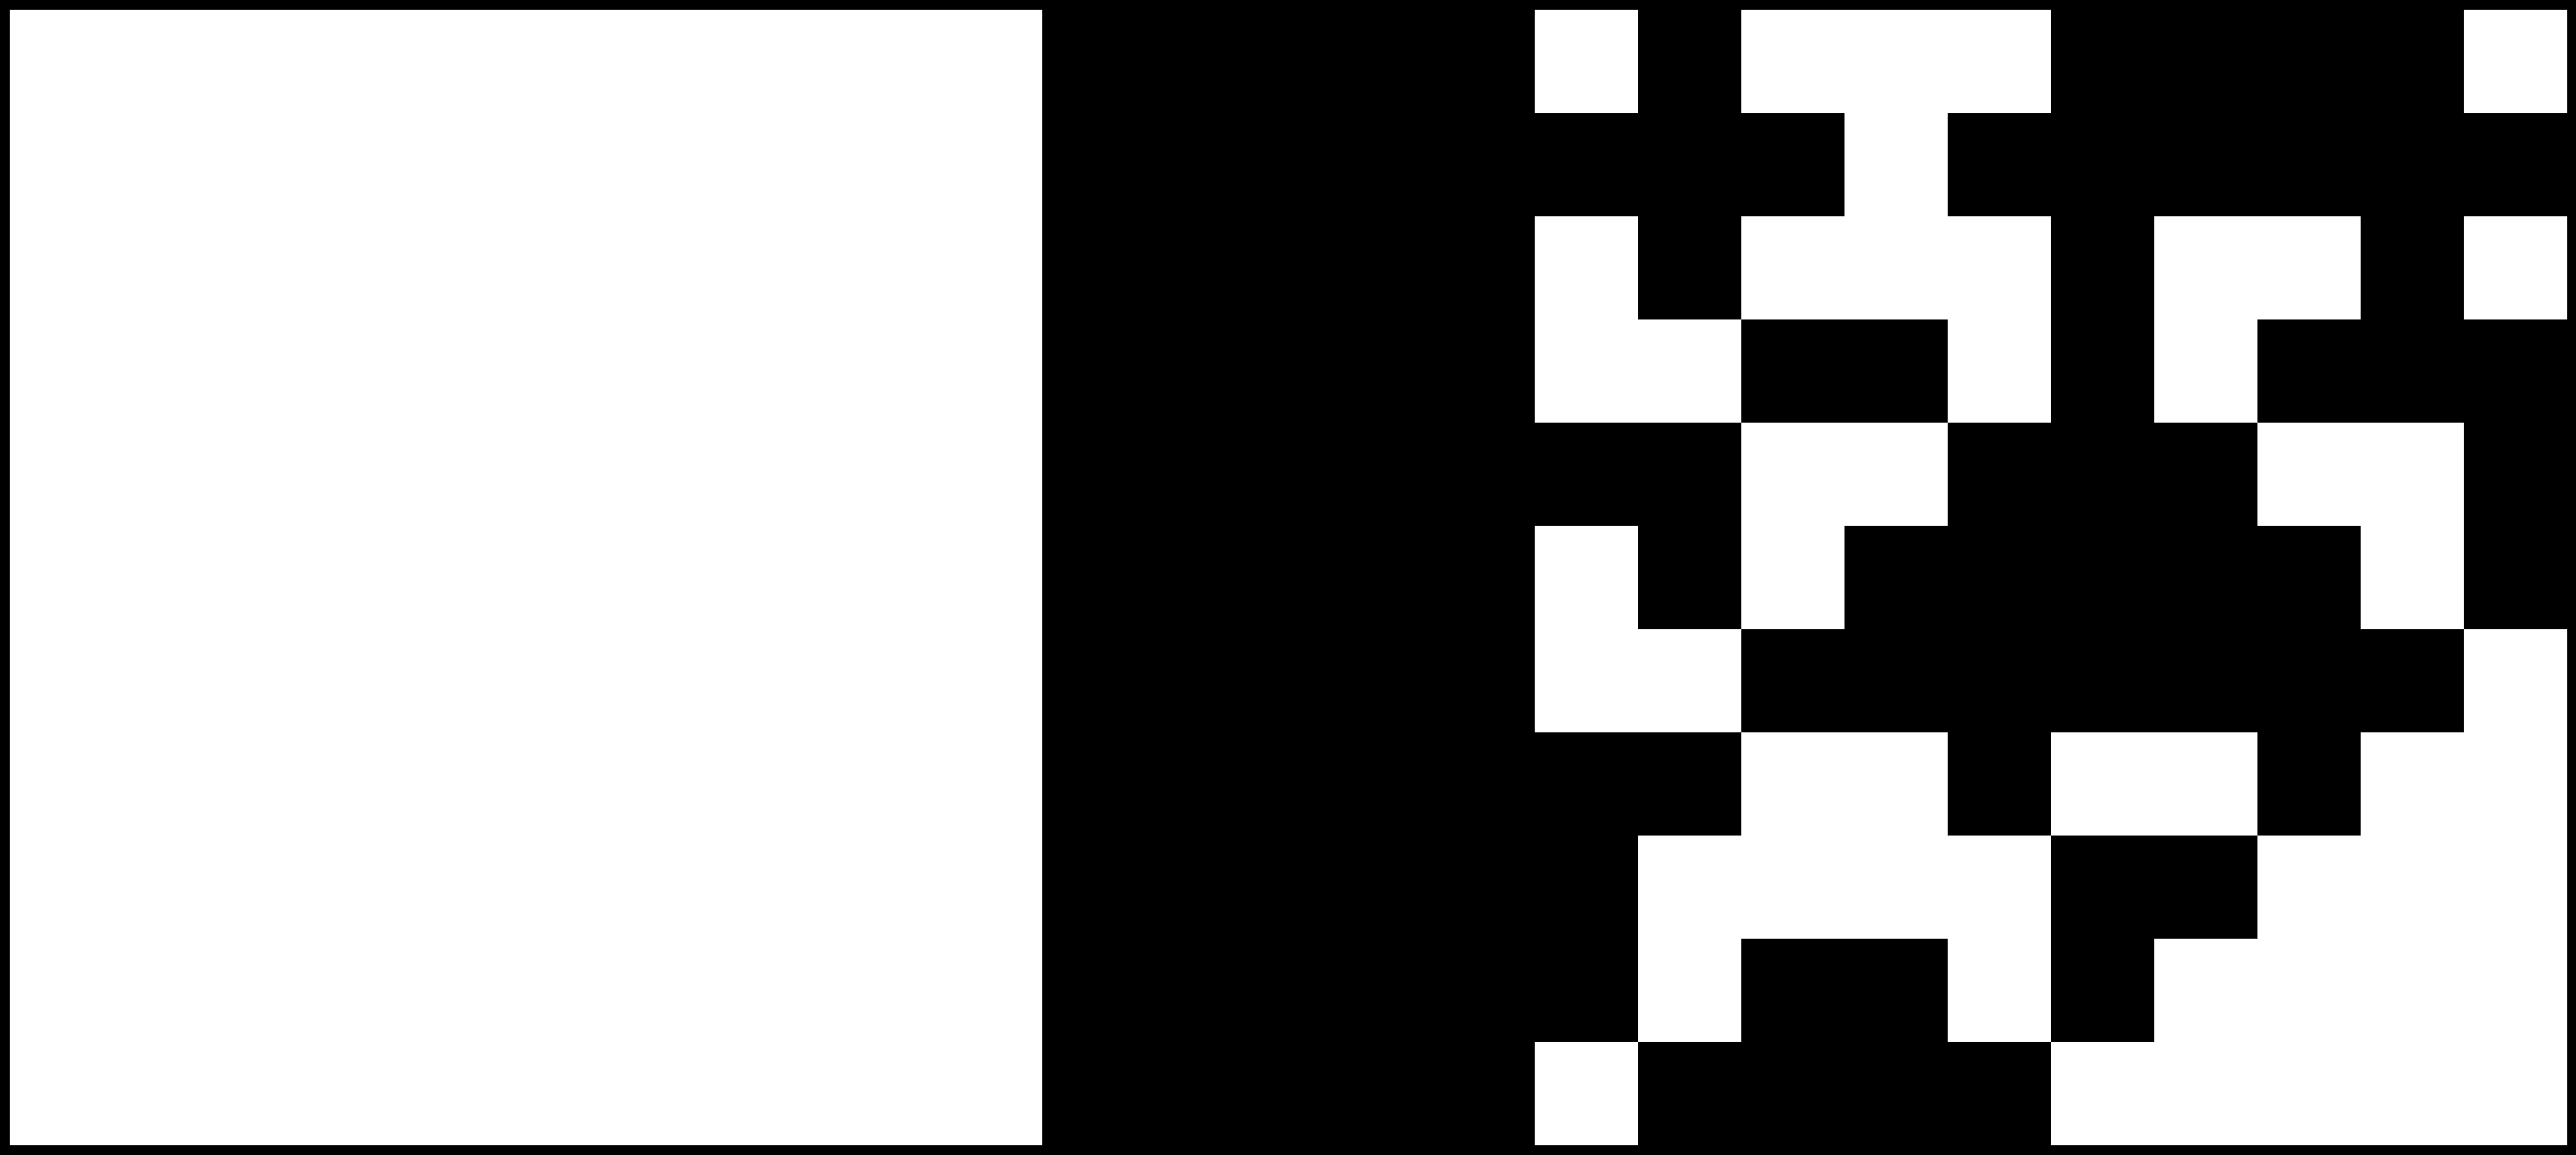

In [58]:
plot_grid_multiple([probabilistic_dynamics(23, 10, [1,2,3,4], [0.5,0.5,0.5,0.5], 10), dynamics(23, 10, [1,2,3,4], 10)], cols=3)

plot_grid_multiple([probabilistic_dynamics(90, 10, [1,2,3,4], [0.5,0.5,0.5,0.5], 10), dynamics(90, 10, [1,2,3,4], 10)], cols=3)

plot_grid_multiple([probabilistic_dynamics(150, 10, [1,2,3,4], [0.5,0.5,0.5,0.5], 10), dynamics(150, 10, [1,2,3,4], 10)], cols=3)

## 5. Creating Markov Chains for semiclassicla CA
The function for a semiclassical Markov chain will have the same structure as the previous Markov chain but instead of values of 1 and 0 corresponding to 100 and 0% you get values within the range of 0 and 1 corresponding to different probabilities. NO

The matrix itself will not change because the evolution is still deterministic and has no associated probability, what will change is the vectorized initial conditions.

In [59]:
def vectorized_ic_probabilistic(L, initial_conditions, probability_list: list):
    import itertools
    
    # build the lattice row — length L
    row = np.zeros(L, dtype=int)
    for i, probability in zip(initial_conditions, probability_list):
        row[i] = 1 if random.random() < probability else 0       
    
    # find which index in all_states this corresponds to
    all_states = list(itertools.product([0, 1], repeat=L))
    index      = all_states.index(tuple(row))  
    
    # return a vector of length 2^L with a 1 at that index
    v = np.zeros(2**L, dtype=int)
    v[index] = 1
    return v

But can we use Markov chains to simulate a probabilistic evolution, let's say that for each binary number that maps out to one, we can denote a certain probability that it actually does map to one, whereas the combinations that map out to zero always do map out to zero.

In [60]:
def markov_matrix_mapping_probabilistic(rule_number: int, L: int, p: float):
    all_states   = list(itertools.product([0, 1], repeat=L))
    n = len(all_states)
    M = np.zeros((n, n), dtype=float)

    state_labels = [''.join(str(b) for b in s) for s in all_states]
    print(f"\nProbabilistic Transition matrix — Rule {rule_number}, L={L}, p={p}")
    print(f"Row = next state   Col = current state\n")
    print("        " + "  ".join(state_labels))
    print("       " + "---" * n)

    for j, state in enumerate(all_states):
        nxt = next_state(state, rule_number, L)

        # bits that rule maps to 0 → always 0
        # bits that rule maps to 1 → 1 with probability p, else 0
        probabilistic_nxt = tuple(
            1 if (bit == 1 and random.random() < p) else 0
            for bit in nxt
        )

        i        = all_states.index(probabilistic_nxt)
        M[i][j]  = 1
        label    = ''.join(str(b) for b in state)
        row      = "  ".join(f"{M[k][j]:.0f}" for k in range(n))
        print(f"{label}  |  {row}")



def markov_matrix_probabilistic(rule_number: int, L: int, p: float):
    all_states = list(itertools.product([0, 1], repeat=L))
    n = len(all_states)
    M = np.zeros((n, n), dtype=float)

    for j, state in enumerate(all_states):
        nxt = next_state(state, rule_number, L)  # deterministic next state

        # build the probabilistic next state
        probabilistic_nxt = tuple(
            1 if (bit == 1 and random.random() < p) else 0
            for bit in nxt
        )
        # bit == 0 → always stays 0
        # bit == 1 → becomes 1 with probability p, else 0

        i = all_states.index(probabilistic_nxt)
        M[i][j] = 1

    return M

Another approach to a probabilistic Markov chain is simulating noise by giving it a random probability such that the mapping is not performed and instead the output is flipped:

In [61]:
def markov_matrix_noise(rule_number: int, L: int, probability: float):
    """
    Normal CA transition matrix but every bit in the output
    has a small probability epsilon of flipping.
    
    probability = 0.0 → identical to normal deterministic markov_matrix
    probability = 0.5 → completely random, rule means nothing
    probability = 1 → like if the rule was inversed
    """

    all_states = list(itertools.product([0, 1], repeat=L))
    n  = len(all_states)
    M = np.zeros((n, n), dtype=float)

    for j, state in enumerate(all_states):
        nxt = next_state(state, rule_number, L)  # deterministic next state

        # apply bit-flip noise to every bit in nxt
        noisy_nxt = tuple(
            (1 - bit) if random.random() < probability else bit
            for bit in nxt
        )

        i = all_states.index(noisy_nxt)
        M[i][j] = 1

    return M

## 6. Semiclassical Cellular Automata: How they are defined and how to build them with matrices
We will take the definition of semiclassical cellular automata is close to the third definition, a regular cellular automata where there is a probability that the state of a cell is flipped and that is taken as the current timestep when computing the following timestep.

The previous function doesn't take into account the state of the system after the bits are flipped as the state which to use for the computation of the following matrix and no probability matrix (decimal values as the values of the elements) is computed.

In [62]:
def semiclassical_markov_matrix(rule_number: int, L: int, probability: float):
   
    all_states = list(itertools.product([0, 1], repeat=L))
    n = len(all_states)
    M = np.zeros((n, n), dtype=float)

    for j, state in enumerate(all_states):
        for noisy_state in all_states:
            # probability of this particular noisy version of `state`
            
            p_noise = 1.0
            for bit, noisy_bit in zip(state, noisy_state):
                p_noise *= probability if bit != noisy_bit else (1 - probability)
            if p_noise == 0.0:
                continue
            nxt = next_state(noisy_state, rule_number, L)  # deterministic rule on the noisy input
            i = all_states.index(nxt)
            M[i, j] += p_noise   # accumulate — several noisy states can map to the same next state

    return M

In [63]:
print(semiclassical_markov_matrix(200, 2, 0.5))

print(semiclassical_markov_matrix(200, 2, 0.25))

print(semiclassical_markov_matrix(200, 2, 0.0))

[[0.75 0.75 0.75 0.75]
 [0.   0.   0.   0.  ]
 [0.   0.   0.   0.  ]
 [0.25 0.25 0.25 0.25]]
[[0.9375 0.8125 0.8125 0.4375]
 [0.     0.     0.     0.    ]
 [0.     0.     0.     0.    ]
 [0.0625 0.1875 0.1875 0.5625]]
[[1. 1. 1. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 1.]]


In [64]:
print(semiclassical_markov_matrix(200, 2, 1.0))

print(semiclassical_markov_matrix(45, 2, 0.338929))

[[0. 1. 1. 1.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [1. 0. 0. 0.]]
[[0.         0.         0.         0.        ]
 [0.22405613 0.43701487 0.11487287 0.22405613]
 [0.338929   0.338929   0.661071   0.661071  ]
 [0.43701487 0.22405613 0.22405613 0.11487287]]


The function has the same constraint as all previous markov functions, where the time taken to compute the matrix scales non-linearly with L.

The spectral properties of general stochastic matrices and these semiclassical matrices will be looked at subsequently.

However, now let's define a dynamics fucntion that will replace the matrix multiplication as to not be affected by its constraints.

In [75]:
def semiclassical_dynamics(rule_number, L, initial_conditions, timesteps, probability):
    if not (0 <= rule_number <= 255):
        raise ValueError("Rule number not appropiate")
    rule = make_rule(rule_number)

    row = np.zeros(L, dtype=int)
    for i in initial_conditions:
        row[i] = 1
    rows = [row.copy()]  

    for _ in range(timesteps):
        prev = rows[-1]
        noisy_prev = np.array([
            1 - bit if random.random() < probability else bit
            for bit in prev
        ])
        new_row = np.zeros(L, dtype=int)
        for j in range(L):
            left   = str(int(noisy_prev[j-1])) if j > 0 else '0'
            centre = str(int(noisy_prev[j]))
            right  = str(int(noisy_prev[j+1])) if j < L-1 else '0'
            new_row[j] = rule[left+centre+right]
        rows.append(new_row)

    grid = np.array(rows[::-1])
    return grid

## 7. Spectral properties of these matrices
### 7.1) Defining the spectral properties 
The spectral properties of a matrix depend on the spectrum or range of the eigenvalues. The eigenvalues and eigenvectors can be obtained through integrated numpy fucntions:

In [66]:
import numpy as np
M = np.array([[1,2,3], 
              [4,5,6], 
              [7,8,9]]) #use a stochastic matrix

M = np.array([[0,0.5,0.7], 
              [0,5,0.1], 
              [1,0,0.2]])
eigenvalues, eigenvectors = np.linalg.eig(M)

For square matrices, the determinant and trace are also obtained through integrated functions. In the case of our Markov matrices, the trace will be the number of states where the state maps out to itself and the determinant will almost always be zero as that means multiple states map out to the same state, if that is not the case, then that means the system will be reversible.

In [67]:
det = np.linalg.det(M)

trace = np.trace(M)

print(det, trace)

def is_reversible_matrix(M):
    if np.linalg.det(M) != 0:
        return True
    else:
        return False

is_reversible_matrix(M)

-3.4499999999999993 5.2


True

The spectral radius is the largest absolute eigenvalue in the spectrum. It is related to its exponential growth as the matrix is raised to the nth power and n tends to infinity. But in stochastic matrices it is always one.

In [68]:
import numpy as np

def spectral_radius(M):
    eigenvalues = np.linalg.eig(M)[0]
    return np.max(np.abs(eigenvalues)) #should always equal one for stochastic matrices

print(spectral_radius(M))

5.002143988952626


The spectral gap is the difference between largets and second largest eigenvalue:

In [69]:
import numpy as np

def spectral_gap(M):
    eigenvalues = np.abs(np.linalg.eig(M)[0])  
    eigenvalues = sorted(eigenvalues, reverse=True) 
    eigenvalue_max_1 = eigenvalues[0]  
    eigenvalue_max_2 = eigenvalues[1]   
    return eigenvalue_max_1 - eigenvalue_max_2

print(spectral_gap(M))

4.066860193937612


The algebraic multiplicity is the number of times an eigenvalue is repeated (power of the root of the characteristic polynomial). The geometric multiplicity is the number of linearly independent eigenvectors or dimension of the eigenspace:

In [70]:
import numpy as np

M = np.array([[1, 0, 0, 1],
              [0, 1, 1, 0],
              [0, 1, 1, 0],
              [1, 0, 0, 1]])

def algebraic_multiplicities(M):
    eigvals = np.linalg.eigvals(M) # Direct way to get eigenvalues without slicing
    
    unique_vals = []
    counts = []

    for v in eigvals:
        found = False
        for i, u in enumerate(unique_vals):
            if np.isclose(v, u):
                counts[i] += 1
                found = True
                break
        if not found:
            unique_vals.append(v)
            counts.append(1)

    return list(zip(unique_vals, counts)) # Dictionaries behave strangely with float numbers, so just use tuples in lists

print(algebraic_multiplicities(M))

[(2.0, 2), (0.0, 2)]


In [71]:
def geometric_multiplicities(M):
    eigenvalues = np.linalg.eigvals(M)
    n = M.shape[0]
    
    results = {}
    for lam in eigenvalues:
        lam_r = round(lam.real, 10)
        if lam_r not in results:
            null_dim = n - np.linalg.matrix_rank(M - lam * np.eye(n))
            results[lam_r] = null_dim

    print(f"{'Eigenvalue':>15}  {'Geom. Mult.':>12}")
    print("-" * 30)
    for lam, gm in sorted(results.items(), key=lambda x: -abs(x[0])):
        print(f"{lam:>15.6f}  {gm:>12}")

    return results

print(geometric_multiplicities(M))

     Eigenvalue   Geom. Mult.
------------------------------
       2.000000             2
       0.000000             2
{2.0: 2, 0.0: 2}


In [72]:
M = np.array([[2, 1],
              [0, 2]])


print(algebraic_multiplicities(M))   
print(geometric_multiplicities(M)) 

[(2.0, 2)]
     Eigenvalue   Geom. Mult.
------------------------------
       2.000000             1
{2.0: 1}


Let's verify these functions for a stochastic matrix:

In [73]:
M = np.array([
    [0.7, 0.2, 0.9],  
    [0.2, 0.5, 0.0],  
    [0.1, 0.3, 0.1],])

print()
print("Determinant: ", np.linalg.det(M))
print("Trace: ", np.trace(M))
print("Reversible?: ", is_reversible_matrix(M))
print("Spectral radius: ", spectral_radius(M))
print("Spectral gap: ", spectral_gap(M))
print("Algebraic multiplicity: ", algebraic_multiplicities(M))
print("Algebraic multiplicity: ", geometric_multiplicities(M)) 


Determinant:  0.04000000000000001
Trace:  1.3
Reversible?:  True
Spectral radius:  1.0000000000000002
Spectral gap:  0.8000000000000003
Algebraic multiplicity:  [((1.0000000000000002+0j), 1), ((0.14999999999999983+0.1322875655532296j), 1), ((0.14999999999999983-0.1322875655532296j), 1)]
     Eigenvalue   Geom. Mult.
------------------------------
       1.000000             1
       0.150000             1
Algebraic multiplicity:  {1.0: 1, 0.15: 1}


### 7.2) Spectral properties of general stochastic matrices

Levin, Peres, Wilmer — Markov Chains and Mixing Times

A stochastic matrix must always follow the following rules:
- There is always an eigenvalue equal to one.
- The stationary distribution lives in the left eigenspace.
- All eigenvalues lie inside or on the unit disk.
- The spectral gap controls convergence speed.

Generally, the parameters in the matrix that yield the most information on the state of the system are the following:
- Eigenvalue of 1 (largest eigenvalue as well): Means that there is long-term behaviour.
- Second largest eigenvalue: Measures the memory decay rate, if it approaches one it means it "remmebers its past for a long time", if it approaches zero, it forgets its past quite fast.
- Spectral gap (positive difference between the largest and second largest eigenvalue): If there is a large gap (remmebers past), then it achieves equilibrium faster. If there is a small gap (doesn't remember past), then it takes longer to acheive equilibrium.
It measures how strongly the system pullls towards equilibrium at each step.
- The uniqueness of eigenvalue 1 is related to the connectivity structure: If the eigenvalue of 1 has a geometric multiplicity of one, then the entire system behaves together, if otherwise, the system can be decomposed into smaller systems that don't behave with each other.
- The presence of any eigenvalue near the unit circle is indicative of the exixtence of metastable states (also evidencing why it takes longer to converge).

### 7.3) Spectral Properties of Our Semiclassical CA Matrices

#### 7.3.1) If the probability is zero or one, the they are deterministic cellular automata systems
The probability parameter is the probability that each cell is randomly flipped onto its oppossite state. Therefore, if the probability is zero, then the matrix outputted will be the same as the output for the deterministic matrix, as long as the length and rule number are the same.


In [76]:
L = 10
ic = [0,5,8]
timesteps = 100

for i in range(256):
    if np.allclose(dynamics(i, L, ic, timesteps), semiclassical_dynamics(i, L, ic, timesteps, 0)) == False:
        raise ValueError("Function not working")

print("All well")


All well


Additionally, if the probability is one, the evolution is deterministic and can be predicted with absolute certainty, tough it may be computationally expensive.

In [79]:
L = 10
ic = [0,5,8]
timesteps = 100

for i in range(256):
    if np.allclose(semiclassical_dynamics(i, L, ic, timesteps, 1), semiclassical_dynamics(i, L, ic, timesteps, 1)) == False:
        raise ValueError("Function not working")

print("All well")


All well


This doesn't hold for a decimal probability:

In [86]:
L = 10
ic = [0,5,8]
timesteps = 100

for i in range(256):
    if np.allclose(semiclassical_dynamics(i, L, ic, timesteps, 0.7), semiclassical_dynamics(i, L, ic, timesteps, 0.7)) == False:
        print(f"Rule {i} not working")
    else:
        print(f"Rule {i} works")



Rule 0 works
Rule 1 not working
Rule 2 not working
Rule 3 not working
Rule 4 not working
Rule 5 not working
Rule 6 not working
Rule 7 not working
Rule 8 not working
Rule 9 not working
Rule 10 not working
Rule 11 not working
Rule 12 not working
Rule 13 not working
Rule 14 not working
Rule 15 not working
Rule 16 not working
Rule 17 not working
Rule 18 not working
Rule 19 not working
Rule 20 not working
Rule 21 not working
Rule 22 not working
Rule 23 not working
Rule 24 not working
Rule 25 not working
Rule 26 not working
Rule 27 not working
Rule 28 not working
Rule 29 not working
Rule 30 not working
Rule 31 not working
Rule 32 not working
Rule 33 not working
Rule 34 not working
Rule 35 not working
Rule 36 not working
Rule 37 not working
Rule 38 not working
Rule 39 not working
Rule 40 not working
Rule 41 not working
Rule 42 not working
Rule 43 not working
Rule 44 not working
Rule 45 not working
Rule 46 not working
Rule 47 not working
Rule 48 not working
Rule 49 not working
Rule 50 not work

Rule 0 and 255 work because they have the same output regardless of the input.

#### 7.3.2) Eigenvalue 1 always survives
We will now verify numerically that the largest eigenvalue for all stochastic matrices is one:

In [90]:
import random

L=0
rng = random.random()

for i in range(256):
    M = semiclassical_markov_matrix(i, L, rng)
    if not max(np.linalg.eig(M)[1]) == 1:
        raise ValueError("Matrix is not stochastic")

print("All well")

All well


#### 7.3.3) Reversibility breaks down under noise
The randomness inside a semiclassical system peaks at a probability of 0.5 and does down as it gets nearer o and 1.

In that case, then as the probability gets closer to 0.5, the determinant of the matrix gets closer to 0.

Found 10 reversible rules: [51, 60, 90, 102, 105, 150, 153, 165, 195, 204]

Rule 51 (deterministically reversible):
  p=0.0    det(M) = 1.000e+00   reversible? True
  p=0.001  det(M) = 1.000e+00   reversible? True
  p=0.01   det(M) = 0.000e+00   reversible? False
  p=0.05   det(M) = 0.000e+00   reversible? False
  p=0.1    det(M) = 0.000e+00   reversible? False
  p=0.3    det(M) = 0.000e+00   reversible? False
  p=0.5    det(M) = 0.000e+00   reversible? False

Rule 60 (deterministically reversible):
  p=0.0    det(M) = 1.000e+00   reversible? True
  p=0.001  det(M) = 1.000e+00   reversible? True
  p=0.01   det(M) = 0.000e+00   reversible? False
  p=0.05   det(M) = 0.000e+00   reversible? False
  p=0.1    det(M) = 0.000e+00   reversible? False
  p=0.3    det(M) = 0.000e+00   reversible? False
  p=0.5    det(M) = 0.000e+00   reversible? False

Rule 90 (deterministically reversible):
  p=0.0    det(M) = 1.000e+00   reversible? True
  p=0.001  det(M) = 1.000e+00   reversible? True
  p=0.01

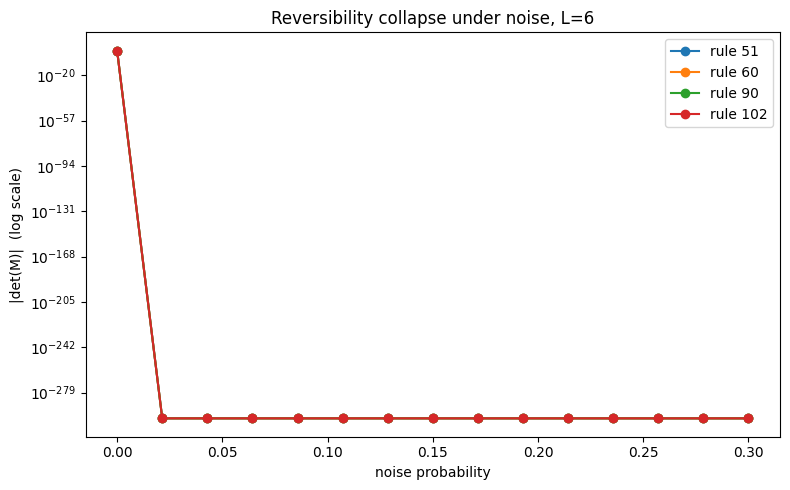

In [92]:
def det_vs_noise(rule_number, L, probabilities):
    dets = []
    for p in probabilities:
        M = markov_matrix_noise(rule_number, L, p)
        dets.append(abs(np.linalg.det(M)))
    return np.array(dets)

reversible_rules = [i for i in range(256) if is_reversible(i)]
print(f"Found {len(reversible_rules)} reversible rules: {reversible_rules}")

L = 6
probabilities = [0.0, 0.001, 0.01, 0.05, 0.1, 0.3, 0.5]

for rule in reversible_rules[:4]:
    dets = det_vs_noise(rule, L, probabilities)
    print(f"\nRule {rule} (deterministically reversible):")
    for p, det in zip(probabilities, dets):
        M = markov_matrix_noise(rule, L, p)
        print(f"  p={p:<6} det(M) = {det:.3e}   reversible? {is_reversible_matrix(M)}")

plt.figure(figsize=(8, 5))
for rule in reversible_rules[:4]:
    dets = det_vs_noise(rule, L, np.linspace(0, 0.3, 15))
    plt.semilogy(np.linspace(0, 0.3, 15), dets + 1e-300, marker='o', label=f'rule {rule}')
plt.xlabel('noise probability')
plt.ylabel('|det(M)|  (log scale)')
plt.title(f'Reversibility collapse under noise, L={L}')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Inverse matrices of stochastic matrices and their stochacity
### 8.1) Reviewing inversibility in classical elementary CA
If the matrix that describes a transition is singular, then the system is not reversible, which is the case in most classical cases.

Semiclassical cellular automata behave the same way, if the matrix is singular, then it is not reversible and reversibility will depend on the same parameters as the classical case (boundary conditions, rule number, initial conditions and lattice length) as well as the probabilities imposed on the initial conditions.

### 8.2) Properties of the inverses of stochastic matrices in semiclassical cellular automata
In the general case for stochastic matrices, its inverse will not preserve stochacity, however, general intuition leads us to believe that is not the case with semiclassical CA. Most matrices will not have an inverse, but the ones that do will have an inverse that is stochastic because it is describing the evolution from one state to the other in a probabilistic environment. 

In the case of classical cellular automata it is a permutation matrix.

https://www.statlect.com/matrix-algebra/permutation-matrix

In the case that randomness is added, then the underlying matrix loses its status as a permutation matrix and the inverse is not stochastic, which is in line with the fact that noisy systems have it more difficult to be traced back.

In the classical case, markov matrices will almost never be reversible because the systems they represnet will almost never be reversible.

We can now look at the properties of these matrices and compare them with their inverse:

In [ ]:
import numpy as np

def random_stochastic_matrix(n, axis=1, rng=None):
    rng = rng or np.random.default_rng()
    m = rng.random((n, n))
    return m / m.sum(axis=axis, keepdims=True)

In [ ]:
for i in range(256):
    try:
        a = np.linalg.inv(markov_matrix(i))
        print(i)
    except:

        continue   

# ___________

## Summary:
- Found a way to model the evolution that a rule represents as a transition matrix for the case of classical cellular automata.
- Studied the properties of said transition matrices
- Conducted the same matrix modeling with semiclassical cellular automata.
- Created probabilistic versions of previously defined functions but for semiclassical cellular automata.
- Talked about their characteristics
- Defined functions relevant for the spectral properties of matrices, looked at general stochastic matrices.
- Retook the concept of invertability in Notebook 2 and saw how matrices fitted into it.
- Argued why semiclassical CA should have a degree of randomness such that they do not exhibit reversability and their respective matrices will not have an inverse.
- Studied the inverse of classical stochastic matrices and argued about their stochacity.